In [18]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from scipy.sparse import csr_matrix

In [19]:
# Load datset
df = pd.read_csv("/content/events.csv")

In [20]:
# First few lines of dataset
df.head()

,timestamp,visitorid,event,itemid,transactionid
0,1433221332117,257597,view,355908,NaN
1,1433224214164,992329,view,248676,NaN
2,1433221999827,111016,view,318965,NaN
3,1433221955914,483717,view,253185,NaN
4,1433221337106,951259,view,367447,NaN


In [21]:
# Check Data types
df.dtypes

,0
timestamp,int64
visitorid,int64
event,object
itemid,int64
transactionid,float64


In [22]:
# Statistical information of dataset
df.describe()

,timestamp,visitorid,itemid,transactionid
count,2.756101e+06,2.756101e+06,2.756101e+06,22457.000000
mean,1.436424e+12,7.019229e+05,2.349225e+05,8826.497796
std,3.366312e+09,4.056875e+05,1.341954e+05,5098.996290
min,1.430622e+12,0.000000e+00,3.000000e+00,0.000000
25%,1.433478e+12,3.505660e+05,1.181200e+05,4411.000000
50%,1.436453e+12,7.020600e+05,2.360670e+05,8813.000000
75%,1.439225e+12,1.053437e+06,3.507150e+05,13224.000000
max,1.442545e+12,1.407579e+06,4.668670e+05,17671.000000


In [23]:
# Check for null values
df.isnull().sum()

,0
timestamp,0
visitorid,0
event,0
itemid,0
transactionid,2733644


In [24]:
df['event'].unique()

array(['view', 'addtocart', 'transaction'], dtype=object)

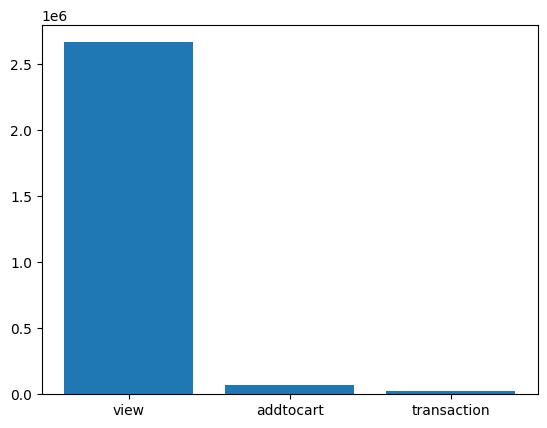

In [25]:
plt.bar(df['event'].unique(),df['event'].value_counts())
plt.show()

We see that transaction id contains these much null values , it is because of transition id only occur for event = 'transaction'.

In [26]:
# Check for duplicates
print(df.duplicated().sum())

460


In [27]:
df.drop_duplicates(inplace=True)

In [28]:
print(df.duplicated().sum())

0


In [29]:
# Mapping
event_weights={
    'view':1,
    'addtocart':2,
    'transaction':3
}
df['interaction_score']=df['event'].map(event_weights)

In [30]:
print(df['interaction_score'].tail())

2756096    1
2756097    1
2756098    1
2756099    1
2756100    1
Name: interaction_score, dtype: int64


In [31]:
# Group by visitorid , itemid
df = df.groupby(['visitorid', 'itemid'], as_index=False)['interaction_score'].max()


In [32]:
# Label encoding
user_encoder = LabelEncoder()
item_encoder = LabelEncoder()

df['user_idx'] = user_encoder.fit_transform(df['visitorid'])
df['item_idx'] = item_encoder.fit_transform(df['itemid'])


In [33]:
# User item matrix
user_item_sparse = csr_matrix(
    (df['interaction_score'], (df['user_idx'], df['item_idx']))
)


In [34]:
print(user_item_sparse)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 2145179 stored elements and shape (1407580, 235061)>
  Coords	Values
  (0, 33901)	1
  (0, 144072)	1
  (0, 180182)	1
  (1, 36440)	1
  (2, 108948)	1
  (2, 130961)	1
  (2, 163762)	1
  (2, 172691)	1
  (3, 194003)	1
  (4, 89515)	1
  (5, 31115)	1
  (6, 33030)	2
  (6, 127790)	1
  (6, 173653)	1
  (7, 70414)	1
  (7, 83183)	1
  (7, 113960)	1
  (8, 218660)	1
  (9, 111986)	1
  (10, 125303)	1
  (11, 225766)	1
  (12, 35503)	1
  (13, 140404)	1
  (13, 161451)	1
  (14, 166275)	1
  :	:
  (1407563, 196632)	1
  (1407564, 181820)	1
  (1407565, 94350)	1
  (1407566, 180080)	1
  (1407567, 92542)	1
  (1407567, 110319)	1
  (1407568, 31818)	1
  (1407569, 77132)	1
  (1407570, 120245)	1
  (1407571, 57241)	1
  (1407572, 61678)	1
  (1407573, 7021)	1
  (1407573, 29244)	1
  (1407573, 41633)	1
  (1407573, 58855)	1
  (1407573, 116825)	1
  (1407573, 118675)	1
  (1407573, 183002)	1
  (1407573, 233536)	1
  (1407574, 207267)	1
  (1407575, 61283)	1
  (1407576, 17948